# EDA

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [2]:
df = pd.read_csv("data/eda.csv")
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000,2014-10-13,221900.000
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000,2014-12-09,538000.000
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000,2015-02-25,180000.000
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000,2014-12-09,604000.000
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000,2015-02-18,510000.000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float64
 18  sqft_lot15     21

In [4]:
# Convert bedrooms to integer (removes the .000 entirely)
df['bedrooms'] = df['bedrooms'].astype(int)
# Convert floors to integer (removes the .000 entirely)
df['floors'] = df['floors'].astype(int)



# Fill 0 instead of NaN to fix missing data 
df['yr_renovated'] = df['yr_renovated'].fillna(0)
df['waterfront'] = df['waterfront'].fillna(0)
df['sqft_basement'] = df['sqft_basement'].fillna(0)
df['view'] = df['view'].fillna(0)

# Convert waterfront and view to integer (removes the .000 entirely)
df['waterfront'] = df['waterfront'].astype(int)
df['view'] = df['view'].astype(int)

# Convert year renovated to integer + fix the mistake in format writing 
df["yr_renovated"] = df["yr_renovated"].apply(
    lambda x: x / 10 if x > 9999 else x
)
df['yr_renovated'] = df['yr_renovated'].astype(int)

# Round to .xx and only show .xx for the whole dataframe
df = df.round(2)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3,1.00,1180.00,5650.00,1,0,0,3,7,...,0.00,1955,0,98178,47.51,-122.26,1340.00,5650.00,2014-10-13,221900.00
1,6414100192,3,2.25,2570.00,7242.00,2,0,0,3,7,...,400.00,1951,1991,98125,47.72,-122.32,1690.00,7639.00,2014-12-09,538000.00
2,5631500400,2,1.00,770.00,10000.00,1,0,0,3,6,...,0.00,1933,0,98028,47.74,-122.23,2720.00,8062.00,2015-02-25,180000.00
3,2487200875,4,3.00,1960.00,5000.00,1,0,0,5,7,...,910.00,1965,0,98136,47.52,-122.39,1360.00,5000.00,2014-12-09,604000.00
4,1954400510,3,2.00,1680.00,8080.00,1,0,0,3,8,...,0.00,1987,0,98074,47.62,-122.04,1800.00,7503.00,2015-02-18,510000.00


In [5]:
df.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
count,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00,21597.00
mean,4580474287.77,3.37,2.12,2080.32,15099.41,1.45,0.01,0.23,3.41,7.66,1788.60,285.75,1971.00,68.76,98077.95,47.56,-122.21,1986.62,12758.28,540296.57
std,2876735715.75,0.93,0.77,918.11,41412.64,0.55,0.08,0.76,0.65,1.17,827.76,439.82,29.38,364.04,53.51,0.14,0.14,685.23,27274.44,367368.14
min,1000102.00,1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,3.00,370.00,0.00,1900.00,0.00,98001.00,47.16,-122.52,399.00,651.00,78000.00
25%,2123049175.00,3.00,1.75,1430.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,98033.00,47.47,-122.33,1490.00,5100.00,322000.00
50%,3904930410.00,3.00,2.25,1910.00,7618.00,1.00,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,98065.00,47.57,-122.23,1840.00,7620.00,450000.00
75%,7308900490.00,4.00,2.50,2550.00,10685.00,2.00,0.00,0.00,4.00,8.00,2210.00,550.00,1997.00,0.00,98118.00,47.68,-122.12,2360.00,10083.00,645000.00
max,9900000190.00,33.00,8.00,13540.00,1651359.00,3.00,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,98199.00,47.78,-121.32,6210.00,871200.00,7700000.00


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'sqft_living'}>],
       [<Axes: title={'center': 'sqft_lot'}>,
        <Axes: title={'center': 'floors'}>,
        <Axes: title={'center': 'waterfront'}>,
        <Axes: title={'center': 'view'}>],
       [<Axes: title={'center': 'condition'}>,
        <Axes: title={'center': 'grade'}>,
        <Axes: title={'center': 'sqft_above'}>,
        <Axes: title={'center': 'sqft_basement'}>],
       [<Axes: title={'center': 'yr_built'}>,
        <Axes: title={'center': 'yr_renovated'}>,
        <Axes: title={'center': 'zipcode'}>,
        <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'sqft_living15'}>,
        <Axes: title={'center': 'sqft_lot15'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

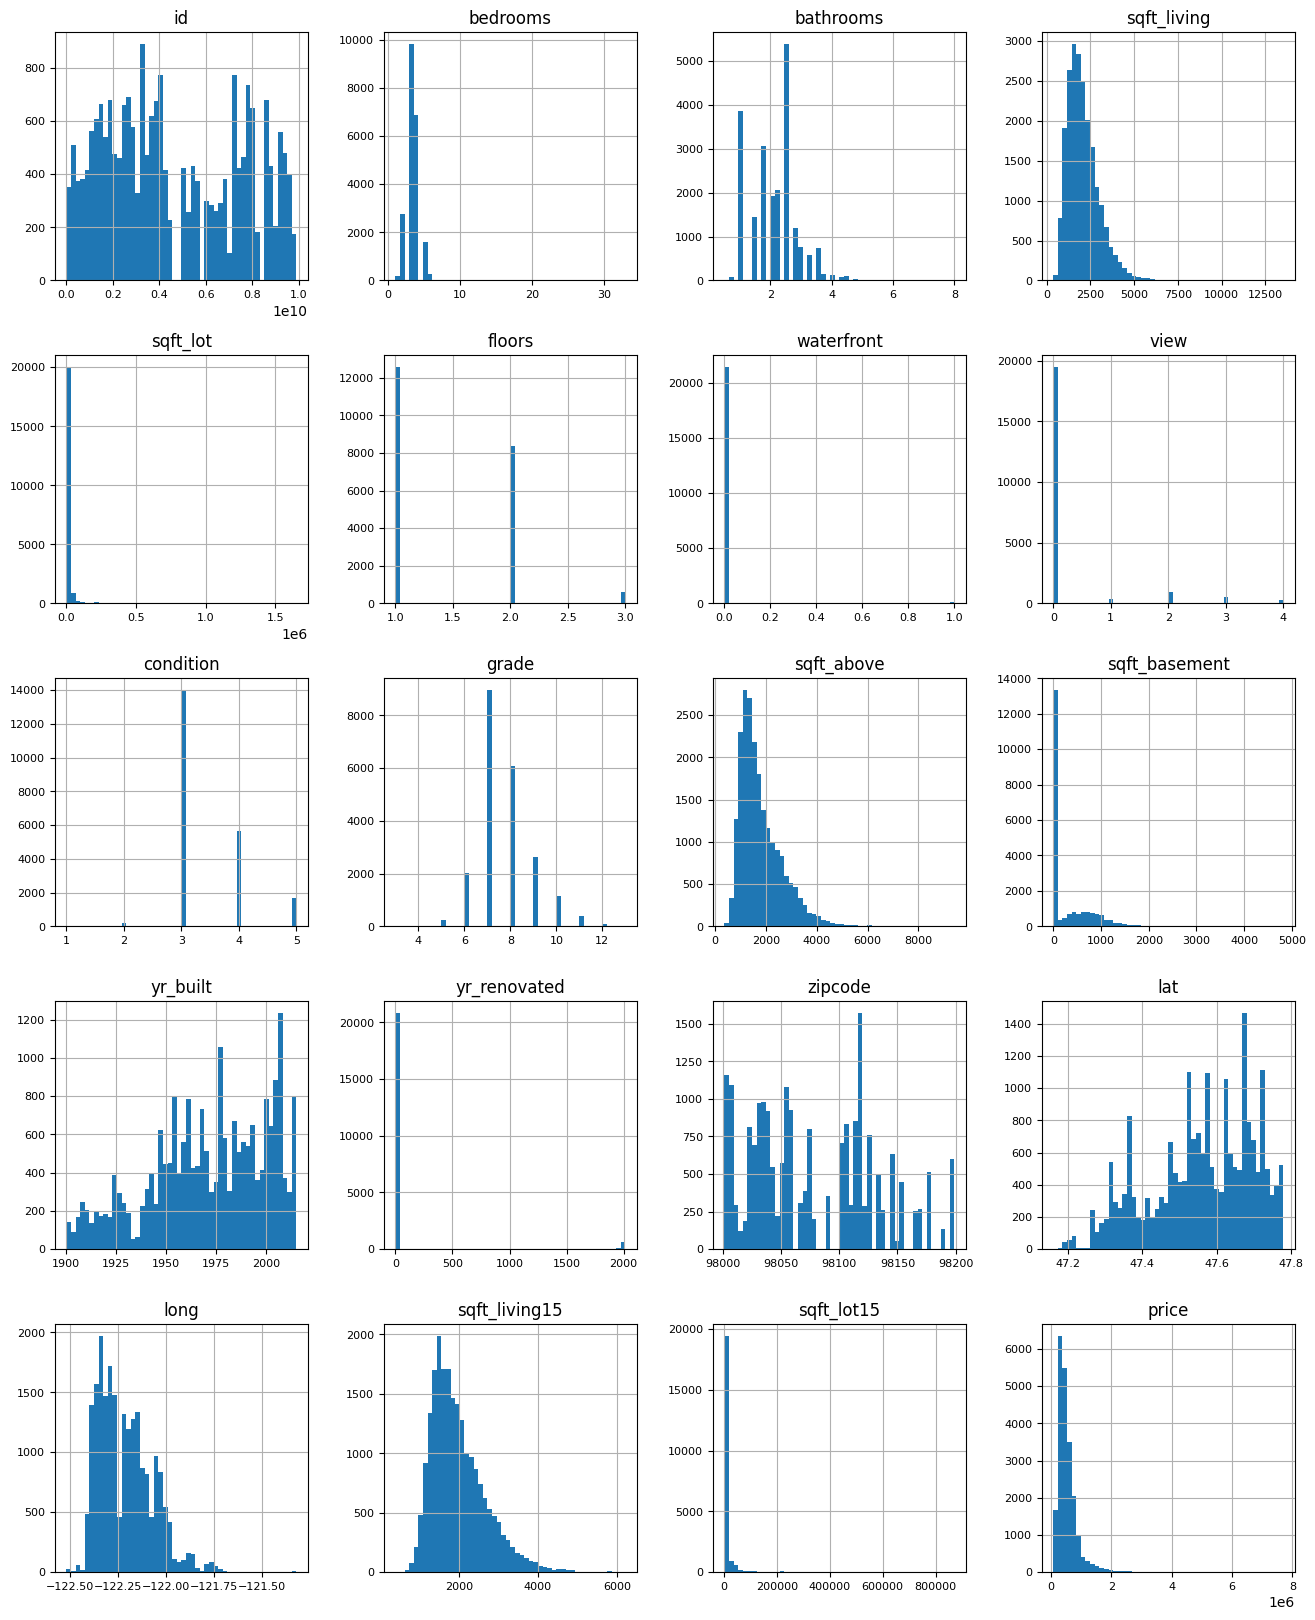

In [6]:
#Lets's plot all the data to get the better understanding of the distribution
df.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

In [7]:
# Finding the features most correlated with the price of the houses 
df_num = df.select_dtypes(include = ['float64', 'int64'])
#df_num.head()

df_num = df_num.corr()['price'][:-1] # -1 because the latest row is SalePrice
golden_features_list = df_num[abs(df_num) > 0.5].sort_values(ascending=False)
print("There is {} strongly correlated values with SalePrice:\n{}".format(len(golden_features_list), golden_features_list))


There is 5 strongly correlated values with SalePrice:
sqft_living     0.70
grade           0.67
sqft_above      0.61
sqft_living15   0.59
bathrooms       0.53
Name: price, dtype: float64


['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'price']


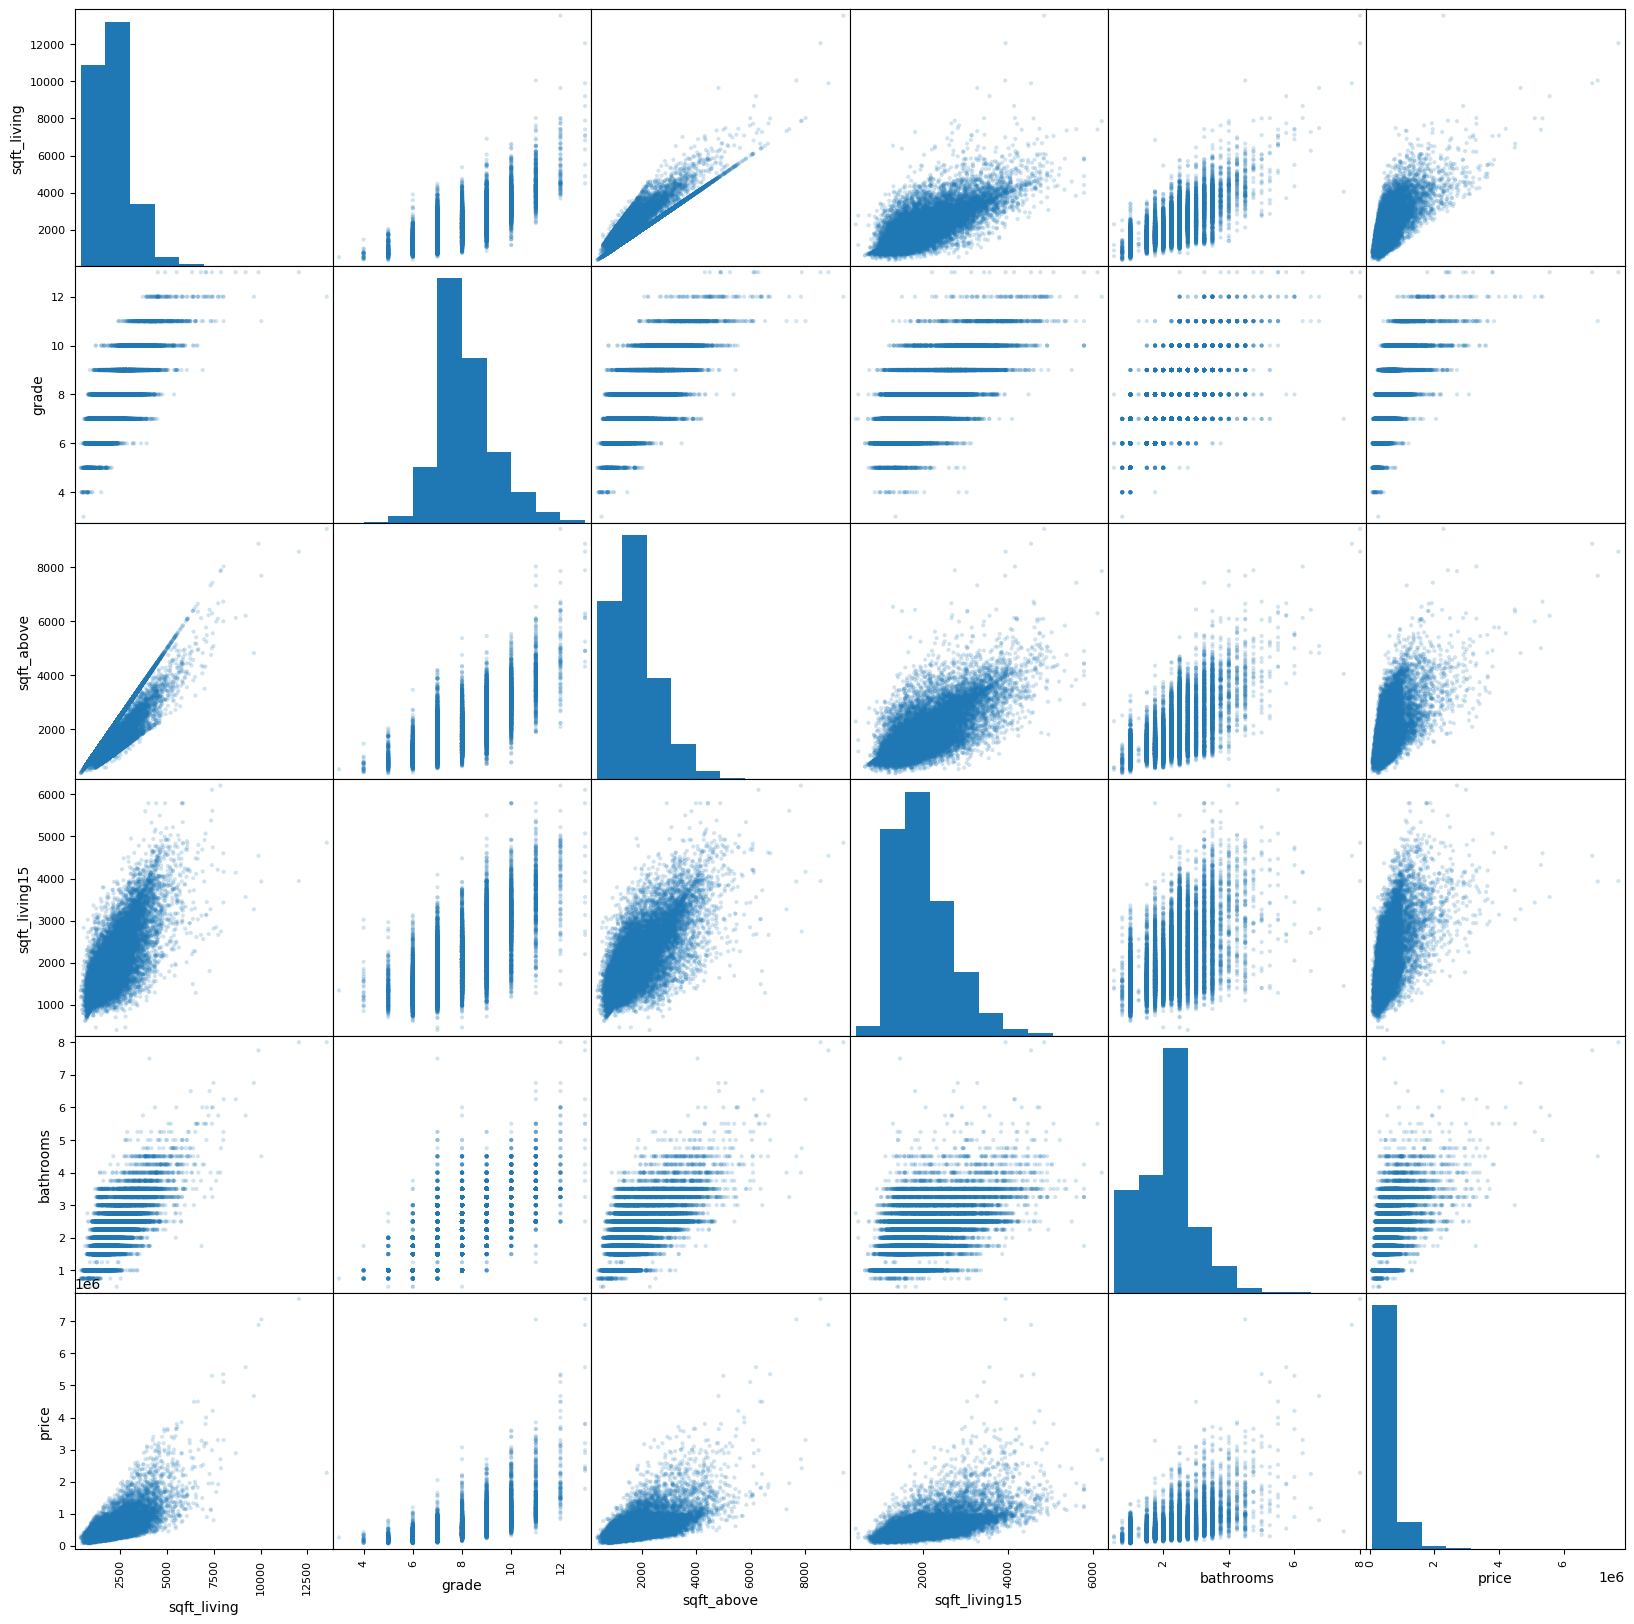

In [8]:
# Scatter-plotting 5 mist correlated ones

from pandas.plotting import scatter_matrix

df_num = df.select_dtypes(include=['float64', 'int64'])
print(df_num.columns.tolist())
cols = golden_features_list.index.tolist() + ['price']
scatter_matrix(df_num[cols], figsize=(20, 20), alpha=0.2, diagonal='hist')
plt.show()


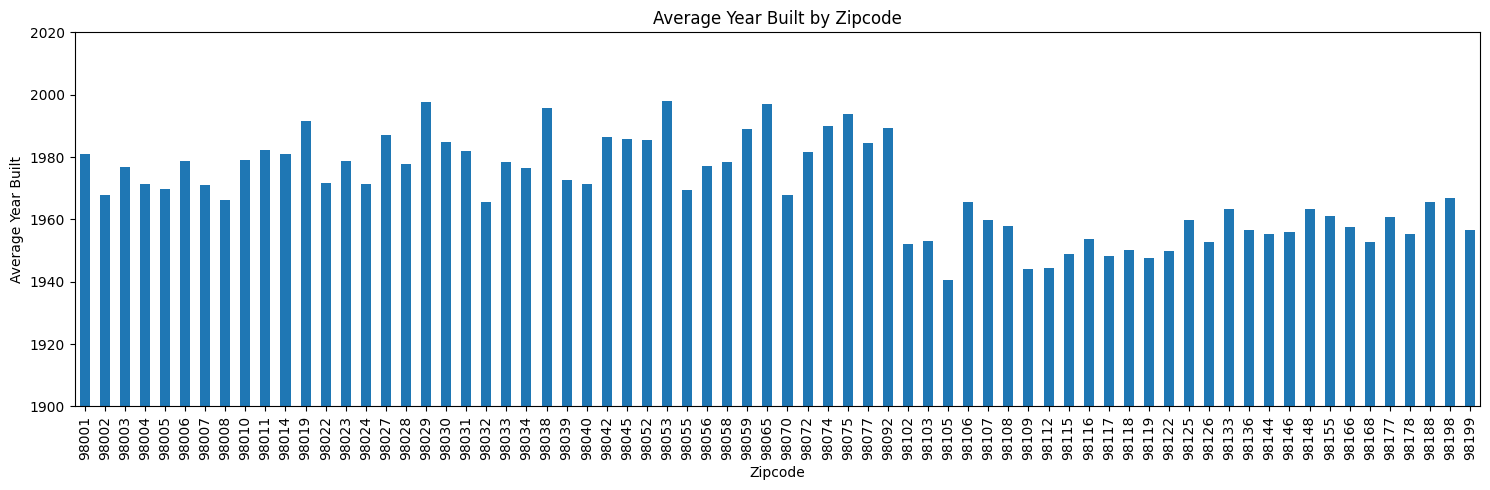

In [9]:
# Finding out historical houses
# In general, good baseline is houses built before 1920 (according to internet research)
# Interesting metric could be to see average age of built per zipcode

# Let's start from checking how many zipcodes are we talking about. UPD: 70
df["zipcode"].nunique()
# And calculating average year of built per zipcode
df.groupby('zipcode')['yr_built'].mean().round().astype(int)
# Build a histogram to visualize this metric now
df.groupby('zipcode')['yr_built'].mean().plot(kind='bar', figsize=(15, 5))
plt.xlabel('Zipcode')
plt.ylabel('Average Year Built')
plt.title('Average Year Built by Zipcode')
plt.tight_layout()
plt.ylim(1900, 2020)
plt.show()



In [10]:
# Let's pick houses older than 1920 and form a dataframe with them

df_historical = df[df['yr_built'] < 1920]
df_historical.head()
df_historical.describe()

# WOW!! it's actually 1450 houses, a lot


# And build a dataframe for Jacob's request

df_proposal = df_historical[df_historical['waterfront'] == 0]
df_proposal.head()
df_proposal.shape[0]
# That's just 1441 that are not waterfront, also shocking info. I thought proportion would be different


df_proposal = df_proposal[df_proposal['bathrooms'] >= 4]
df_proposal.head()
df_proposal.shape[0]
# After bathroom count filter we have 17 results


# Checking for the size over 80000
#df_proposal = df_proposal[df_proposal['sqft_lot'] >= 80000]

# There is none for such request. So I'll just sort descending
df_proposal = df_proposal.sort_values('sqft_lot', ascending=False)
df_proposal.head(17)

# Create a list of zipcodes filtered for golf course related request
zipcodes_filtered = [98118,98144,98108,98107,98116,98126,98125,98065,98022,98010,98011,98005]

# See where they overlap
df_proposal = df_proposal[df_proposal['zipcode'].isin(zipcodes_filtered)]
df_proposal.shape[0]
df_proposal.head()

# Got 5!




,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
5961,5249800010,4,4.25,6410.00,43838.00,2,0,2,4,12,...,800.00,1906,0,98144,47.57,-122.28,2270.00,6630.00,2014-12-03,2730000.00
9405,5700003630,5,4.25,4830.00,8050.00,2,0,0,4,11,...,1120.00,1914,0,98144,47.58,-122.29,4470.00,9194.00,2014-06-30,1930000.00
15346,1175000280,4,4.00,1550.00,6596.00,1,0,0,5,7,...,0.00,1907,0,98107,47.67,-122.40,1830.00,4850.00,2014-11-07,707500.00
3582,9272200090,4,4.50,3780.00,6000.00,2,0,4,4,11,...,1010.00,1910,1977,98116,47.59,-122.39,2660.00,6000.00,2015-02-04,1600000.00
6665,475001235,5,4.00,3400.00,5000.00,2,0,0,3,8,...,1080.00,1900,2013,98107,47.67,-122.36,1910.00,5000.00,2014-08-08,870000.00


## Different approach

In [19]:
# And build a dataframe for Jacob's request
df_nowater = df[df['waterfront'] == 0]
df_nowater.head()
df_nowater.shape[0]
# 21451 - almost all have no waterfront. 

21451

In [22]:
#Filter by Jacob's bathroom criterion
df_nwb = df_nowater[(df_nowater['bathrooms'] >= 4)]
df_nwb.shape[0]
# After bathroom count filter we have 380 results


380

# This should already be selecting high-end houses.
let's see the head with highest priced houses on top.

In [36]:
df_nwb.sort_values('price', ascending=False).head(12)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
7245,6762700020,6,8.00,12050.00,27600.00,2,0,3,4,13,...,3480.00,1910,1987,98102,47.63,-122.32,3940.00,8800.00,2014-10-13,7700000.00
9245,9208900037,6,7.75,9890.00,31374.00,2,0,4,3,13,...,1030.00,2001,0,98039,47.63,-122.24,4540.00,42730.00,2014-09-19,6890000.00
4407,2470100110,5,5.75,9200.00,35069.00,2,0,0,3,13,...,3000.00,2001,0,98039,47.63,-122.23,3560.00,24345.00,2014-08-04,5570000.00
1446,8907500070,5,5.00,8000.00,23985.00,2,0,4,3,12,...,1280.00,2009,0,98004,47.62,-122.22,4600.00,21750.00,2015-04-13,5350000.00
12358,6065300370,5,6.00,7440.00,21540.00,2,0,0,3,12,...,1890.00,2003,0,98006,47.57,-122.19,4740.00,19329.00,2015-05-06,4210000.00
4145,6447300265,4,5.50,7080.00,16573.00,2,0,0,3,12,...,1320.00,2008,0,98039,47.62,-122.22,3140.00,15996.00,2014-10-14,4000000.00
19002,2303900100,3,4.25,5510.00,35000.00,2,0,4,3,13,...,600.00,1997,0,98177,47.73,-122.37,3430.00,45302.00,2014-09-11,3800000.00
7028,853200010,5,5.50,7050.00,42840.00,1,0,2,4,13,...,2730.00,1978,0,98004,47.62,-122.22,5070.00,20570.00,2014-07-01,3800000.00
19133,3625049042,5,6.00,5490.00,19897.00,2,0,0,3,12,...,0.00,2005,0,98039,47.62,-122.24,2910.00,17600.00,2014-10-11,3640000.00
5874,2525049148,5,5.00,5450.00,20412.00,2,0,0,3,11,...,0.00,2014,0,98039,47.62,-122.24,3160.00,17825.00,2014-10-07,3420000.00


Yes we have room to filter further, and very highly values houses for our high end customer. 
Let's see about the plot size. How do the top 10 to 50 look like?

In [35]:
df_nwb.sort_values('sqft_lot', ascending=False).head(12)


,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
20436,1125079111,4,5.50,6530.00,871200.00,2,0,2,3,11,...,0.00,2008,0,98014,47.66,-121.88,1280.00,858132.00,2015-04-15,1600000.00
9705,225079036,4,4.00,5545.00,871200.00,2,0,0,3,11,...,1940.00,2003,0,98014,47.68,-121.88,3420.00,871200.00,2015-01-07,937500.00
19076,2623069010,5,4.00,4720.00,493534.00,2,0,0,5,9,...,760.00,1975,0,98027,47.45,-122.01,2160.00,219542.00,2015-01-16,745000.00
18273,1524079188,4,5.25,5240.00,320917.00,2,0,2,3,10,...,0.00,2006,0,98024,47.56,-121.90,1930.00,68824.00,2014-07-29,1860000.00
10543,1522039105,3,4.25,3300.00,308080.00,2,0,2,4,9,...,780.00,1976,0,98070,47.40,-122.42,2130.00,90604.00,2015-01-15,729000.00
12764,1225069038,7,8.00,13540.00,307752.00,3,0,4,3,12,...,4130.00,1999,0,98053,47.67,-121.99,4850.00,217800.00,2014-05-05,2280000.00
11968,3425069083,4,4.50,4225.00,284011.00,2,0,0,4,11,...,0.00,1985,0,98074,47.61,-122.02,2870.00,14576.00,2014-06-25,1010000.00
21328,8835770170,5,6.00,6880.00,279968.00,2,0,3,3,12,...,2810.00,2007,0,98045,47.46,-121.78,4690.00,256803.00,2014-08-22,1490000.00
20251,8835800010,4,4.50,4920.00,270236.00,2,0,3,3,10,...,1100.00,2006,0,98045,47.47,-121.78,4920.00,260924.00,2014-12-23,1040000.00
8619,823069044,5,4.00,4460.00,269345.00,2,0,4,3,9,...,1130.00,1996,0,98027,47.50,-122.06,2670.00,115434.00,2015-03-25,833450.00


## This starts getting interesting. To be able to accomodate a swimming pool and/or tennis courts, Jacob will need at least 2000 square meters or roughly 20k sqft lot or even a 30k sqft.  Let's see how much it narrows the list to.

In [ ]:
#Filter by Jacob's bathroom criterion
df_nwbl = df_nwb[(df_nwb['sqft_lot'] >= 30000)]
df_nwbl.shape[0]
# After bathroom count filter we have 81 results, still decent room to play with, so let's continue!

81

In [37]:
# how does the head look, orederd by descending price? 
df_nwb.sort_values('price', ascending=False).head(12)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
7245,6762700020,6,8.00,12050.00,27600.00,2,0,3,4,13,...,3480.00,1910,1987,98102,47.63,-122.32,3940.00,8800.00,2014-10-13,7700000.00
9245,9208900037,6,7.75,9890.00,31374.00,2,0,4,3,13,...,1030.00,2001,0,98039,47.63,-122.24,4540.00,42730.00,2014-09-19,6890000.00
4407,2470100110,5,5.75,9200.00,35069.00,2,0,0,3,13,...,3000.00,2001,0,98039,47.63,-122.23,3560.00,24345.00,2014-08-04,5570000.00
1446,8907500070,5,5.00,8000.00,23985.00,2,0,4,3,12,...,1280.00,2009,0,98004,47.62,-122.22,4600.00,21750.00,2015-04-13,5350000.00
12358,6065300370,5,6.00,7440.00,21540.00,2,0,0,3,12,...,1890.00,2003,0,98006,47.57,-122.19,4740.00,19329.00,2015-05-06,4210000.00
4145,6447300265,4,5.50,7080.00,16573.00,2,0,0,3,12,...,1320.00,2008,0,98039,47.62,-122.22,3140.00,15996.00,2014-10-14,4000000.00
19002,2303900100,3,4.25,5510.00,35000.00,2,0,4,3,13,...,600.00,1997,0,98177,47.73,-122.37,3430.00,45302.00,2014-09-11,3800000.00
7028,853200010,5,5.50,7050.00,42840.00,1,0,2,4,13,...,2730.00,1978,0,98004,47.62,-122.22,5070.00,20570.00,2014-07-01,3800000.00
19133,3625049042,5,6.00,5490.00,19897.00,2,0,0,3,12,...,0.00,2005,0,98039,47.62,-122.24,2910.00,17600.00,2014-10-11,3640000.00
5874,2525049148,5,5.00,5450.00,20412.00,2,0,0,3,11,...,0.00,2014,0,98039,47.62,-122.24,3160.00,17825.00,2014-10-07,3420000.00


Looks good enough, still a decent number of choices of high-end houses. 
Now we need to figure out the proximity to Golf courses or historic places/districts. 
Looking at the map of golf courses, there are very many. Jacob may be subject to a short drive no matter what. 
Defining HISTORIC districts is more complex, there is no official list or demarcation to use as reference. 
A separate internet search narrows the zip codes that can be considered historic based on the presence of historic landmarks, and with golf courses in them. Let's filter the 81 houses in these zip codes and see if we have decent choices. 

In [ ]:

# Create a list of zipcodes filtered for golf course related request
zipcodes_filtered = [98118,98144,98108,98107,98116,98126,98125,98065,98022,98010,98011,98005]

# See where they overlap
df_histgolf = df_nwbl[df_nwbl['zipcode'].isin(zipcodes_filtered)]
df_histgolf.shape[0]
#df_histgolf.head()

# Got 6!


6

Enough filtering for now. Let's see their headline characteristics in a small table.

In [ ]:
df_histgolf.drop(columns=[
 'waterfront',
 'sqft_above',
 'sqft_basement',
 ])

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
1054,5416300240,4,4.50,5670.00,84267.00,2,2,3,11,2008,0,98010,47.32,-122.04,4100.00,83729.00,2015-02-02,935000.00
5961,5249800010,4,4.25,6410.00,43838.00,2,2,4,12,1906,0,98144,47.57,-122.28,2270.00,6630.00,2014-12-03,2730000.00
11871,2806300070,5,4.00,4850.00,36450.00,2,0,3,10,1977,0,98005,47.64,-122.16,3850.00,35325.00,2014-05-21,975000.00
12565,2806300065,4,4.00,4430.00,31353.00,2,0,3,12,1998,0,98005,47.64,-122.16,3900.00,35237.00,2015-04-22,1960000.00
14802,1525059261,5,4.50,5160.00,44315.00,2,0,3,12,1996,0,98005,47.66,-122.15,4760.00,44315.00,2015-05-05,1900000.00
14885,2125059163,4,5.00,4110.00,43560.00,2,0,4,11,1978,0,98005,47.64,-122.18,3650.00,43995.00,2014-07-03,1040000.00
